Quantum states, gates and operations

This notebook is a guided, interactive follow-up to the chapter section on **quantum states and operations**.

It focuses on the ideas from the pages you shared:

- single-qubit states and amplitudes,
- quantum gates as unitary matrices,
- Pauli gates \(X,Y,Z\),
- Hadamard \(H\), phase \(S\), and \(T\) gates,
- rotations \(R_x, R_y, R_z\),
- multi-qubit states using the Kronecker product,
- entanglement, Bell states, GHZ states, and W states,
- CNOT, SWAP, CZ, and controlled operations.


## 0. Setup

Run this cell first. It defines the basic vectors, matrices, and helper functions used throughout the notebook.

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not available. The notebook will still run, but interactive controls will be disabled.")

np.set_printoptions(precision=3, suppress=True)

# Computational basis states
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

# Superposition states
ket_plus = (ket0 + ket1) / np.sqrt(2)
ket_minus = (ket0 - ket1) / np.sqrt(2)

# Common single-qubit gates
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
S = np.array([[1, 0], [0, 1j]], dtype=complex)
T = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)

GATES = {"I": I, "X": X, "Y": Y, "Z": Z, "H": H, "S": S, "T": T}
STATE_LABELS = {"|0⟩": ket0, "|1⟩": ket1, "|+⟩": ket_plus, "|-⟩": ket_minus}

def normalize(state):
    state = np.asarray(state, dtype=complex)
    norm = np.linalg.norm(state)
    if norm == 0:
        raise ValueError("Cannot normalize the zero vector.")
    return state / norm

def probabilities(state):
    state = normalize(state)
    return np.abs(state) ** 2

def pretty_complex(z, tol=1e-10):
    real = 0 if abs(z.real) < tol else z.real
    imag = 0 if abs(z.imag) < tol else z.imag
    if imag == 0:
        return f"{real:.3g}"
    if real == 0:
        return f"{imag:.3g}i"
    sign = "+" if imag >= 0 else "-"
    return f"{real:.3g} {sign} {abs(imag):.3g}i"

def print_state(state, labels=None):
    state = normalize(np.asarray(state, dtype=complex))
    if labels is None:
        labels = [f"|{i}⟩" for i in range(len(state))]
    for amp, label in zip(state, labels):
        print(f"{label}: {pretty_complex(amp)}")
    print("probabilities:", np.round(np.abs(state)**2, 4))
    print("normalization:", np.round(np.sum(np.abs(state)**2), 6))

def kron(*items):
    result = items[0]
    for item in items[1:]:
        result = np.kron(result, item)
    return result

def basis_labels(n):
    return [f"|{i:0{n}b}⟩" for i in range(2**n)]

def bloch_vector(state):
    state = normalize(np.asarray(state, dtype=complex))
    x = np.real(np.vdot(state, X @ state))
    y = np.real(np.vdot(state, Y @ state))
    z = np.real(np.vdot(state, Z @ state))
    return np.array([x, y, z])

def show_probabilities(state, labels=None, title="Measurement probabilities"):
    state = normalize(np.asarray(state, dtype=complex))
    probs = np.abs(state)**2
    if labels is None:
        labels = [str(i) for i in range(len(probs))]
    plt.figure(figsize=(5, 3))
    plt.bar(labels, probs)
    plt.ylim(0, 1)
    plt.ylabel("Probability")
    plt.title(title)
    plt.show()

def show_bloch_xz(state, title="Bloch sphere slice"):
    state = normalize(np.asarray(state, dtype=complex))
    x, y, z = bloch_vector(state)

    theta = np.linspace(0, 2*np.pi, 300)
    plt.figure(figsize=(4, 4))
    plt.plot(np.cos(theta), np.sin(theta))
    plt.axhline(0)
    plt.axvline(0)
    plt.arrow(0, 0, x, z, head_width=0.04, length_includes_head=True)
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.xlabel("x: |+⟩ / |-⟩")
    plt.ylabel("z: |0⟩ / |1⟩")
    plt.title(title + f"\nBloch vector ≈ ({x:.2f}, {y:.2f}, {z:.2f})")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()

ipywidgets is not available. The notebook will still run, but interactive controls will be disabled.


## 1. Single-qubit states

A single qubit has the form

$
|\psi\rangle = a_0|0\rangle + a_1|1\rangle.
$

The amplitudes \(a_0\) and \(a_1\) are complex numbers.

The probabilities are

$
P(0)=|a_0|^2,\qquad P(1)=|a_1|^2.
$

A valid quantum state must be normalized:

$
|a_0|^2+|a_1|^2=1.
$

Use the sliders below to build a qubit state of the form

$
|\psi\rangle =
\cos\left(\frac{\theta}{2}\right)|0\rangle
+
e^{i\phi}\sin\left(\frac{\theta}{2}\right)|1\rangle.
$


$
|\psi\rangle =
\cos(0.79)|0\rangle
+
e^{i(0.00)}\sin(0.79)|1\rangle
$


|0⟩: 0.707
|1⟩: 0.707
probabilities: [0.5 0.5]
normalization: 1.0


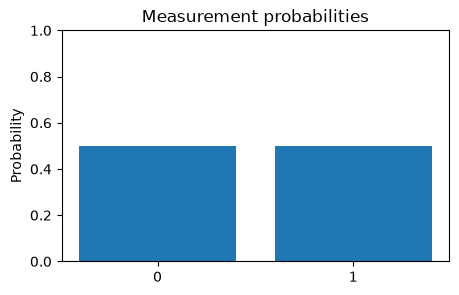

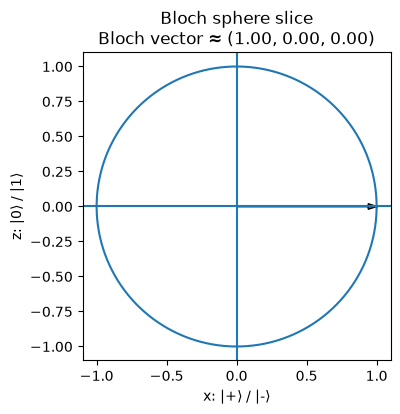

In [67]:
def qubit_from_angles(theta, phi):
    return np.array([
        np.cos(theta / 2),
        np.exp(1j * phi) * np.sin(theta / 2)
    ], dtype=complex)

def explore_single_qubit(theta=np.pi/2, phi=0.0):
    psi = qubit_from_angles(theta, phi)
    display(Markdown(rf"""
$
|\psi\rangle =
\cos({theta/2:.2f})|0\rangle
+
e^{{i({phi:.2f})}}\sin({theta/2:.2f})|1\rangle
$
"""))
    print_state(psi, ["|0⟩", "|1⟩"])
    show_probabilities(psi, ["0", "1"])
    show_bloch_xz(psi)

if WIDGETS_AVAILABLE:
    interact(
        explore_single_qubit,
        theta=widgets.FloatSlider(value=np.pi/2, min=0, max=np.pi, step=0.05, description="theta"),
        phi=widgets.FloatSlider(value=0, min=0, max=2*np.pi, step=0.05, description="phi"),
    )
else:
    explore_single_qubit()

## 2. Gates as unitary matrices

A quantum operation maps one valid quantum state to another valid quantum state.

For a single qubit, gates are \(2\times 2\) unitary matrices.

A matrix \(U\) is unitary when

$
U^\dagger U = I.
$

This condition preserves normalization, so the total probability stays equal to \(1\).

In [68]:
def check_unitary(name, U):
    left = U.conj().T @ U
    print(f"{name}:")
    print("U†U =")
    print(np.round(left, 3))
    print("unitary:", np.allclose(left, I))
    print()

for name, U in GATES.items():
    check_unitary(name, U)

I:
U†U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
unitary: True

X:
U†U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
unitary: True

Y:
U†U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
unitary: True

Z:
U†U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
unitary: True

H:
U†U =
[[ 1.+0.j -0.+0.j]
 [-0.+0.j  1.+0.j]]
unitary: True

S:
U†U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
unitary: True

T:
U†U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
unitary: True



## 3. What common gates do

Some useful single-qubit gates:

$
X|0\rangle = |1\rangle,\qquad X|1\rangle = |0\rangle.
$

So \(X\) acts like a quantum NOT gate.

$
Z|0\rangle = |0\rangle,\qquad Z|1\rangle = -|1\rangle.
$

So \(Z\) changes the phase of \(|1\rangle\).

$
H|0\rangle = |+\rangle,\qquad H|1\rangle = |-\rangle.
$

So \(H\) translates between the computational basis and the plus/minus basis.

Input state: |0⟩
|0⟩: 1
|1⟩: 0
probabilities: [1. 0.]
normalization: 1.0

After applying H:
|0⟩: 0.707
|1⟩: 0.707
probabilities: [0.5 0.5]
normalization: 1.0


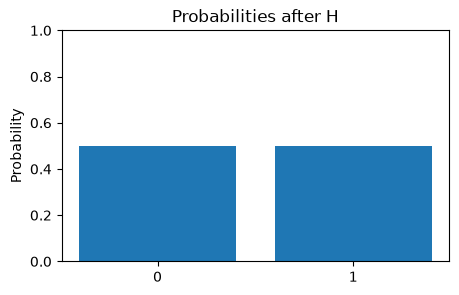

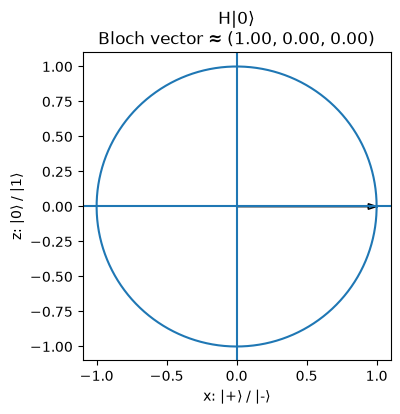

In [69]:
def apply_gate_to_state(gate_name="H", state_name="|0⟩"):
    U = GATES[gate_name]
    psi = STATE_LABELS[state_name]
    out = U @ psi

    print(f"Input state: {state_name}")
    print_state(psi, ["|0⟩", "|1⟩"])
    print()
    print(f"After applying {gate_name}:")
    print_state(out, ["|0⟩", "|1⟩"])
    show_probabilities(out, ["0", "1"], title=f"Probabilities after {gate_name}")
    show_bloch_xz(out, title=f"{gate_name}{state_name}")

if WIDGETS_AVAILABLE:
    interact(
        apply_gate_to_state,
        gate_name=widgets.Dropdown(options=list(GATES.keys()), value="H", description="Gate"),
        state_name=widgets.Dropdown(options=list(STATE_LABELS.keys()), value="|0⟩", description="State"),
    )
else:
    apply_gate_to_state()

## 4. Phase: why \(Z\), \(S\), and \(T\) matter

The gates \(Z\), \(S\), and \(T\) mainly affect **phase**.

$
Z =
\begin{pmatrix}
1 & 0\\
0 & -1
\end{pmatrix},
\qquad
S =
\begin{pmatrix}
1 & 0\\
0 & i
\end{pmatrix},
\qquad
T =
\begin{pmatrix}
1 & 0\\
0 & e^{i\pi/4}
\end{pmatrix}.
$

They do not necessarily change the probability of measuring \(0\) or \(1\) immediately, but they change how the state can interfere later.

A simple demonstration is:

$
H|+\rangle = |0\rangle,
\qquad
H|-\rangle = |1\rangle.
$

The only difference between \(|+\rangle\) and \(|-\rangle\) is relative phase, but after applying \(H\), they produce different classical outcomes.

In [70]:
for label, psi in {"|+⟩": ket_plus, "|-⟩": ket_minus}.items():
    print(f"Input: {label}")
    print("After H:")
    print_state(H @ psi, ["|0⟩", "|1⟩"])
    print("-" * 40)

Input: |+⟩
After H:
|0⟩: 1
|1⟩: 0
probabilities: [1. 0.]
normalization: 1.0
----------------------------------------
Input: |-⟩
After H:
|0⟩: 0
|1⟩: 1
probabilities: [0. 1.]
normalization: 1.0
----------------------------------------


## 5. Rotation gates

The chapter describes rotations around the Bloch sphere axes.

For \(a\in\{x,y,z\}\), a rotation can be written as

$
R_a(\theta)=e^{-i\theta\sigma_a/2}.
$

The Pauli matrices \(\sigma_x,\sigma_y,\sigma_z\) generate rotations around the \(x\), \(y\), and \(z\) axes.

Applying Ry(1.57) to |0⟩
|0⟩: 0.707
|1⟩: 0.707
probabilities: [0.5 0.5]
normalization: 1.0


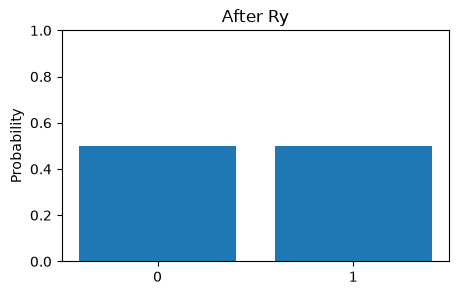

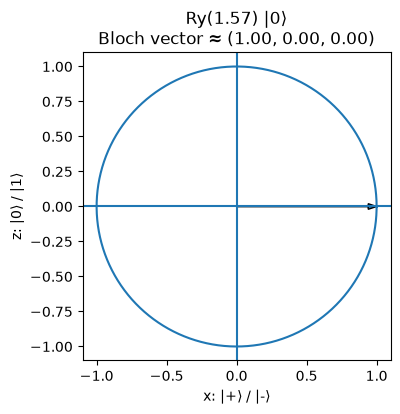

In [71]:
def Rx(theta):
    return np.cos(theta/2)*I - 1j*np.sin(theta/2)*X

def Ry(theta):
    return np.cos(theta/2)*I - 1j*np.sin(theta/2)*Y

def Rz(theta):
    return np.cos(theta/2)*I - 1j*np.sin(theta/2)*Z

ROTATIONS = {"Rx": Rx, "Ry": Ry, "Rz": Rz}

def explore_rotation(rotation="Ry", theta=np.pi/2, state_name="|0⟩"):
    psi = STATE_LABELS[state_name]
    U = ROTATIONS[rotation](theta)
    out = U @ psi

    print(f"Applying {rotation}({theta:.2f}) to {state_name}")
    print_state(out, ["|0⟩", "|1⟩"])
    show_probabilities(out, ["0", "1"], title=f"After {rotation}")
    show_bloch_xz(out, title=f"{rotation}({theta:.2f}) {state_name}")

if WIDGETS_AVAILABLE:
    interact(
        explore_rotation,
        rotation=widgets.Dropdown(options=list(ROTATIONS.keys()), value="Ry", description="Rotation"),
        theta=widgets.FloatSlider(value=np.pi/2, min=0, max=2*np.pi, step=0.05, description="theta"),
        state_name=widgets.Dropdown(options=list(STATE_LABELS.keys()), value="|0⟩", description="State"),
    )
else:
    explore_rotation()

## 6. Multi-qubit states and the Kronecker product

For two qubits, the computational basis is

$
|00\rangle,\ |01\rangle,\ |10\rangle,\ |11\rangle.
$

If

$
|\varphi_1\rangle =
\begin{pmatrix}
a_0\\
a_1
\end{pmatrix},
\qquad
|\varphi_2\rangle =
\begin{pmatrix}
b_0\\
b_1
\end{pmatrix},
$

then the two-qubit product state is

$
|\varphi_1\rangle\otimes|\varphi_2\rangle = \begin{pmatrix}
a_0b_0\\
a_0b_1\\
a_1b_0\\
a_1b_1
\end{pmatrix}.
$

This is the Kronecker product.

|0⟩ ⊗ |1⟩
|00⟩: 0
|01⟩: 1
|10⟩: 0
|11⟩: 0
probabilities: [0. 1. 0. 0.]
normalization: 1.0


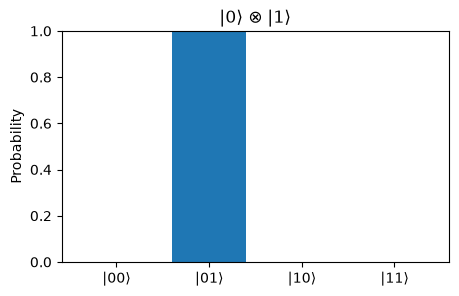

In [72]:
def make_two_qubit_product(first="|0⟩", second="|1⟩"):
    psi1 = STATE_LABELS[first]
    psi2 = STATE_LABELS[second]
    combined = kron(psi1, psi2)

    print(f"{first} ⊗ {second}")
    print_state(combined, basis_labels(2))
    show_probabilities(combined, basis_labels(2), title=f"{first} ⊗ {second}")

if WIDGETS_AVAILABLE:
    interact(
        make_two_qubit_product,
        first=widgets.Dropdown(options=list(STATE_LABELS.keys()), value="|0⟩", description="First"),
        second=widgets.Dropdown(options=list(STATE_LABELS.keys()), value="|1⟩", description="Second"),
    )
else:
    make_two_qubit_product()

## 7. Entanglement

A two-qubit product state can be separated like this:

$
|\psi\rangle = |\varphi_1\rangle\otimes|\varphi_2\rangle.
$

An entangled state cannot be separated into two individual single-qubit states.

A Bell state is

$
|\Phi^+\rangle =
\frac{1}{\sqrt{2}}\left(|00\rangle + |11\rangle\right).
$

If we measure both qubits, the only possible outcomes are \(00\) and \(11\). The outcomes are random, but they are perfectly correlated.

Bell state: Phi+
|00⟩: 0.707
|01⟩: 0
|10⟩: 0
|11⟩: 0.707
probabilities: [0.5 0.  0.  0.5]
normalization: 1.0


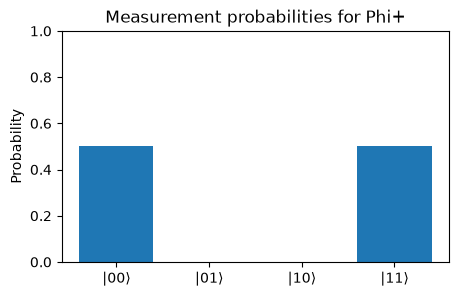

In [73]:
bell_phi_plus = (kron(ket0, ket0) + kron(ket1, ket1)) / np.sqrt(2)
bell_phi_minus = (kron(ket0, ket0) - kron(ket1, ket1)) / np.sqrt(2)
bell_psi_plus = (kron(ket0, ket1) + kron(ket1, ket0)) / np.sqrt(2)
bell_psi_minus = (kron(ket0, ket1) - kron(ket1, ket0)) / np.sqrt(2)

BELL_STATES = {
    "Phi+": bell_phi_plus,
    "Phi-": bell_phi_minus,
    "Psi+": bell_psi_plus,
    "Psi-": bell_psi_minus,
}

def show_bell_state(name="Phi+"):
    state = BELL_STATES[name]
    print(f"Bell state: {name}")
    print_state(state, basis_labels(2))
    show_probabilities(state, basis_labels(2), title=f"Measurement probabilities for {name}")

if WIDGETS_AVAILABLE:
    interact(
        show_bell_state,
        name=widgets.Dropdown(options=list(BELL_STATES.keys()), value="Phi+", description="Bell state"),
    )
else:
    show_bell_state()

## 8. How CNOT creates entanglement

The CNOT gate flips the second qubit when the first qubit is \(1\).

Its action on basis states is

$
|00\rangle \mapsto |00\rangle,
\quad
|01\rangle \mapsto |01\rangle,
\quad
|10\rangle \mapsto |11\rangle,
\quad
|11\rangle \mapsto |10\rangle.
$

If we start with

$
|+\rangle\otimes|0\rangle = \frac{1}{\sqrt{2}}(|00\rangle+|10\rangle),
$

then CNOT produces

$
\frac{1}{\sqrt{2}}(|00\rangle+|11\rangle),
$

which is a Bell state.

Initial state: |+⟩ ⊗ |0⟩
|00⟩: 0.707
|01⟩: 0
|10⟩: 0.707
|11⟩: 0
probabilities: [0.5 0.  0.5 0. ]
normalization: 1.0

After CNOT:
|00⟩: 0.707
|01⟩: 0
|10⟩: 0
|11⟩: 0.707
probabilities: [0.5 0.  0.  0.5]
normalization: 1.0


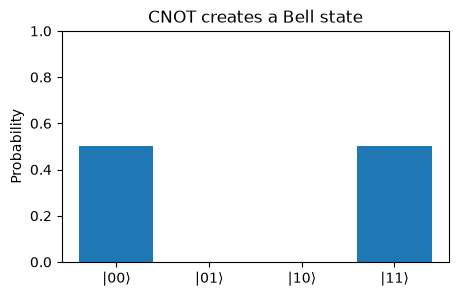

In [74]:
CNOT = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
], dtype=complex)

SWAP = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
], dtype=complex)

CZ = np.diag([1, 1, 1, -1]).astype(complex)

TWO_QUBIT_GATES = {"CNOT": CNOT, "SWAP": SWAP, "CZ": CZ}

initial = kron(ket_plus, ket0)
after = CNOT @ initial

print("Initial state: |+⟩ ⊗ |0⟩")
print_state(initial, basis_labels(2))
print()
print("After CNOT:")
print_state(after, basis_labels(2))
show_probabilities(after, basis_labels(2), title="CNOT creates a Bell state")

## 9. Visualizing two-qubit gates on basis states

CNOT, SWAP, and CZ are important two-qubit gates.

- **CNOT** permutes amplitudes by flipping the target qubit when the control qubit is \(1\).
- **SWAP** exchanges the two qubits.
- **CZ** adds a phase of \(-1\) only to \(|11\rangle\).

CZ may not change measurement probabilities immediately, but its phase matters when later gates cause interference.

Input: |10⟩
Gate: CNOT

Output:
|00⟩: 0
|01⟩: 0
|10⟩: 0
|11⟩: 1
probabilities: [0. 0. 0. 1.]
normalization: 1.0


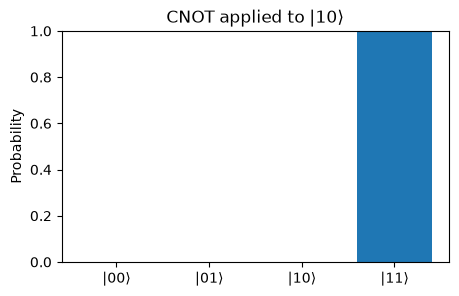

In [75]:
BASIS_2 = {
    "|00⟩": np.array([1, 0, 0, 0], dtype=complex),
    "|01⟩": np.array([0, 1, 0, 0], dtype=complex),
    "|10⟩": np.array([0, 0, 1, 0], dtype=complex),
    "|11⟩": np.array([0, 0, 0, 1], dtype=complex),
}

def apply_two_qubit_gate(gate_name="CNOT", basis_state="|10⟩"):
    U = TWO_QUBIT_GATES[gate_name]
    psi = BASIS_2[basis_state]
    out = U @ psi

    print(f"Input: {basis_state}")
    print(f"Gate: {gate_name}")
    print()
    print("Output:")
    print_state(out, basis_labels(2))
    show_probabilities(out, basis_labels(2), title=f"{gate_name} applied to {basis_state}")

if WIDGETS_AVAILABLE:
    interact(
        apply_two_qubit_gate,
        gate_name=widgets.Dropdown(options=list(TWO_QUBIT_GATES.keys()), value="CNOT", description="Gate"),
        basis_state=widgets.Dropdown(options=list(BASIS_2.keys()), value="|10⟩", description="Input"),
    )
else:
    apply_two_qubit_gate()

## 10. GHZ states and W states

The chapter introduces larger entangled states.

A GHZ state over \(n\) qubits is

$
|GHZ_n\rangle =
\frac{1}{\sqrt{2}}\left(|0^n\rangle + |1^n\rangle\right).
$

For \(n=3\):

$
|GHZ_3\rangle =
\frac{1}{\sqrt{2}}\left(|000\rangle + |111\rangle\right).
$

A W state over \(n\) qubits is the balanced superposition of all bitstrings with exactly one \(1\).

For \(n=3\):

$
|W_3\rangle =
\frac{1}{\sqrt{3}}\left(|001\rangle+|010\rangle+|100\rangle\right).
$

GHZ_3 state
|000⟩: 0.707
|001⟩: 0
|010⟩: 0
|011⟩: 0
|100⟩: 0
|101⟩: 0
|110⟩: 0
|111⟩: 0.707
probabilities: [0.5 0.  0.  0.  0.  0.  0.  0.5]
normalization: 1.0


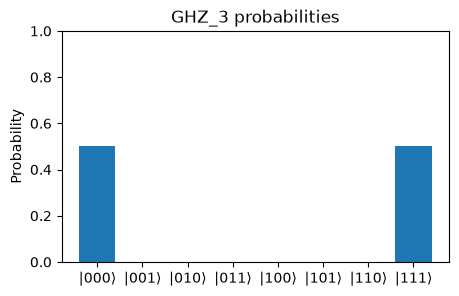

In [76]:
def ghz_state(n):
    state = np.zeros(2**n, dtype=complex)
    state[0] = 1 / np.sqrt(2)
    state[-1] = 1 / np.sqrt(2)
    return state

def w_state(n):
    state = np.zeros(2**n, dtype=complex)
    for bit_position in range(n):
        index = 1 << bit_position
        state[index] = 1 / np.sqrt(n)
    return state

def show_family_state(family="GHZ", n=3):
    if family == "GHZ":
        state = ghz_state(n)
    else:
        state = w_state(n)

    print(f"{family}_{n} state")
    print_state(state, basis_labels(n))
    show_probabilities(state, basis_labels(n), title=f"{family}_{n} probabilities")

if WIDGETS_AVAILABLE:
    interact(
        show_family_state,
        family=widgets.Dropdown(options=["GHZ", "W"], value="GHZ", description="Family"),
        n=widgets.IntSlider(value=3, min=2, max=5, step=1, description="n"),
    )
else:
    show_family_state()

## 11. Controlled operations

The chapter generalizes CNOT and CZ to controlled operations.

A controlled operation applies \(U\) to the target only when the control qubit is \(1\):

$
C(U)=|0\rangle\langle 0|\otimes I
+
|1\rangle\langle 1|\otimes U.
$

That means:

$
C(U)|0\rangle|\phi\rangle = |0\rangle|\phi\rangle
$

and

$
C(U)|1\rangle|\phi\rangle = |1\rangle U|\phi\rangle.
$

So CNOT is \(C(X)\), and CZ is \(C(Z)\).

Controlled-X
Input: |1⟩ ⊗ |0⟩

Output:
|00⟩: 0
|01⟩: 0
|10⟩: 0
|11⟩: 1
probabilities: [0. 0. 0. 1.]
normalization: 1.0


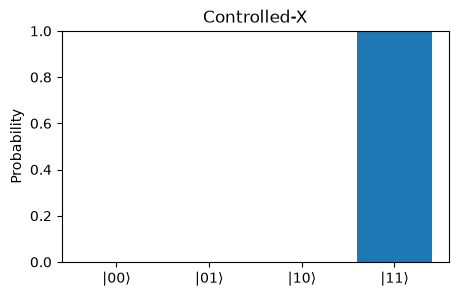

In [77]:
P0 = np.outer(ket0, ket0.conj())
P1 = np.outer(ket1, ket1.conj())

def controlled(U):
    return kron(P0, I) + kron(P1, U)

def explore_controlled(gate_name="X", control_state="|1⟩", target_state="|0⟩"):
    U = GATES[gate_name]
    CU = controlled(U)
    state = kron(STATE_LABELS[control_state], STATE_LABELS[target_state])
    out = CU @ state

    print(f"Controlled-{gate_name}")
    print(f"Input: {control_state} ⊗ {target_state}")
    print()
    print("Output:")
    print_state(out, basis_labels(2))
    show_probabilities(out, basis_labels(2), title=f"Controlled-{gate_name}")

if WIDGETS_AVAILABLE:
    interact(
        explore_controlled,
        gate_name=widgets.Dropdown(options=["X", "Y", "Z", "H", "S", "T"], value="X", description="U"),
        control_state=widgets.Dropdown(options=list(STATE_LABELS.keys()), value="|1⟩", description="Control"),
        target_state=widgets.Dropdown(options=list(STATE_LABELS.keys()), value="|0⟩", description="Target"),
    )
else:
    explore_controlled()

## 12. Channel representation idea

The chapter also mentions a **channel representation** of a single-qubit unitary \(U\), using how \(U\) transforms the Pauli matrices.

The basic idea is:

$
U\sigma_s U^\dagger
$

tells us how the operation rotates the Pauli axes.

For a single qubit, this connects a \(2\times 2\) unitary matrix with a rotation-like action on the Bloch sphere.

In [78]:
PAULIS = {"X": X, "Y": Y, "Z": Z}

def pauli_transfer_matrix(U):
    labels = ["X", "Y", "Z"]
    R = np.zeros((3, 3), dtype=float)

    for r, row_label in enumerate(labels):
        sigma_r = PAULIS[row_label]
        for s, col_label in enumerate(labels):
            sigma_s = PAULIS[col_label]
            R[r, s] = np.real(0.5 * np.trace(sigma_r @ U @ sigma_s @ U.conj().T))

    return R

def show_channel_representation(gate_name="H"):
    U = GATES[gate_name]
    R = pauli_transfer_matrix(U)
    print(f"Pauli/channel representation for {gate_name}:")
    print(np.round(R, 3))
    print()
    print("Rows and columns correspond to X, Y, Z.")

if WIDGETS_AVAILABLE:
    interact(
        show_channel_representation,
        gate_name=widgets.Dropdown(options=list(GATES.keys()), value="H", description="Gate"),
    )
else:
    show_channel_representation()

Pauli/channel representation for H:
[[ 0.  0.  1.]
 [ 0. -1.  0.]
 [ 1.  0.  0.]]

Rows and columns correspond to X, Y, Z.


## 13. Big picture summary

The chapter builds the following chain of ideas:

$
\text{state vector}
\rightarrow
\text{amplitudes}
\rightarrow
\text{probabilities}
\rightarrow
\text{unitary operations}
\rightarrow
\text{multi-qubit systems}
\rightarrow
\text{entanglement}
\rightarrow
\text{controlled gates}.
$

The most important conceptual points are:

1. A quantum state is a normalized vector of amplitudes.
2. Gates are unitary matrices, so they preserve total probability.
3. \(X,Y,Z,H,S,T\) are basic building blocks for changing amplitudes and phases.
4. Multi-qubit states use the Kronecker product.
5. Some multi-qubit states are entangled and cannot be split into separate qubit states.
6. CNOT, CZ, and controlled operations are central because they create and manipulate correlations between qubits.
7. Phase can be invisible in one measurement basis but become visible after interference.